# Lecture 10 (file family L09) · Non-Maximum Suppression, one decision at a time

**One idea:** dense detectors produce several boxes for one object. NMS greedily lets the highest-scoring box claim its high-IoU neighbourhood.

You will predict the decisions, print the complete trace, visualize each iteration, test class-aware NMS, and find a threshold failure case.

**Clock map:** `TRAIN` produces head outputs; `INFER` decodes boxes, forms class scores, filters, and runs NMS; `EVAL` then matches the frozen ranked detections to ground truth. This notebook stays on the `INFER` clock; the companion notebook owns matching and AP.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

TEAL, ORANGE, GREEN, RED, BLUE, SLATE = '#2A7F7F', '#F57C00', '#20A84A', '#E34850', '#2D6FBB', '#59636E'

## 1 · `INFER` — five scored candidates in the held scene

A and B cover cup 1; C and D cover cup 2; E is an isolated false alarm. Scores are A $.95$, B $.90$, E $.89$, C $.88$, D $.75$. Boxes use continuous/half-open corners, so area has no inclusive-pixel `+1`.

**Predict before running:** with $\tau=0.5$, which three boxes should survive?

In [2]:
names = np.array(['A','B','E','C','D'])
boxes = np.array([
    [10,10,50,50],   # A, cup 1
    [12,12,52,52],   # B, duplicate cup 1
    [35, 5,55,25],   # E, isolated false alarm
    [60,15,90,55],   # C, cup 2
    [63,17,91,56],   # D, duplicate cup 2
], float)
scores = np.array([.95,.90,.89,.88,.75])
classes = np.array(['cup','cup','cup','cup','cup'])

In [3]:
def area(b):
    return max(0., b[2]-b[0]) * max(0., b[3]-b[1])

def iou(a,b):
    left, top = max(a[0],b[0]), max(a[1],b[1])
    right, bottom = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0.,right-left) * max(0.,bottom-top)
    union = area(a)+area(b)-inter
    return inter/union if union else 0.

pairwise = np.array([[iou(a,b) for b in boxes] for a in boxes])
print('pairwise IoU, rows/columns A B E C D')
print(np.round(pairwise,3))
print(f'IoU(A,B)={pairwise[0,1]:.3f}; IoU(C,D)={pairwise[3,4]:.3f}')

pairwise IoU, rows/columns A B E C D
[[1.    0.822 0.127 0.    0.   ]
 [0.822 1.    0.124 0.    0.   ]
 [0.127 0.124 1.    0.    0.   ]
 [0.    0.    0.    1.    0.81 ]
 [0.    0.    0.    0.81  1.   ]]
IoU(A,B)=0.822; IoU(C,D)=0.810


## 2 · `INFER` — implement the greedy loop

The kernel below is **class-agnostic**: 1. sort by score; 2. keep the highest remaining box; 3. suppress neighbours with IoU $>\tau$; 4. repeat. Production class-aware NMS runs this kernel independently per class.

The sort is stable, so equal scores preserve input order; other implementations may choose a different tied box. Inspect the trace, not only the final list.

In [4]:
def nms(boxes, scores, threshold=.5):
    order = list(np.argsort(-scores, kind='stable'))
    keep, trace = [], []
    while order:
        i = order.pop(0)
        keep.append(i)
        removed, survivors = [], []
        for j in order:
            overlap = iou(boxes[i], boxes[j])
            if overlap > threshold:
                removed.append((j, overlap))
            else:
                survivors.append(j)
        trace.append({'kept': i, 'removed': removed, 'remaining': survivors.copy()})
        order = survivors
    return keep, trace

keep, trace = nms(boxes, scores, threshold=.5)
for step, event in enumerate(trace,1):
    k = event['kept']
    removed = ', '.join(f'{names[j]} (IoU {ov:.3f})' for j,ov in event['removed']) or 'none'
    remaining = ', '.join(names[event['remaining']]) or 'none'
    print(f'step {step}: keep {names[k]} ({scores[k]:.2f}); suppress {removed}; remaining {remaining}')
print('final survivors:', names[keep].tolist())
assert names[keep].tolist() == ['A','E','C']

step 1: keep A (0.95); suppress B (IoU 0.822); remaining E, C, D
step 2: keep E (0.89); suppress none; remaining C, D
step 3: keep C (0.88); suppress D (IoU 0.810); remaining none
final survivors: ['A', 'E', 'C']


## 3 · `INFER` — see the greedy state change

Slate boxes are undecided, green solid boxes are kept, and red dashed boxes are suppressed. Explain why B disappears before D is even considered, while isolated E survives.

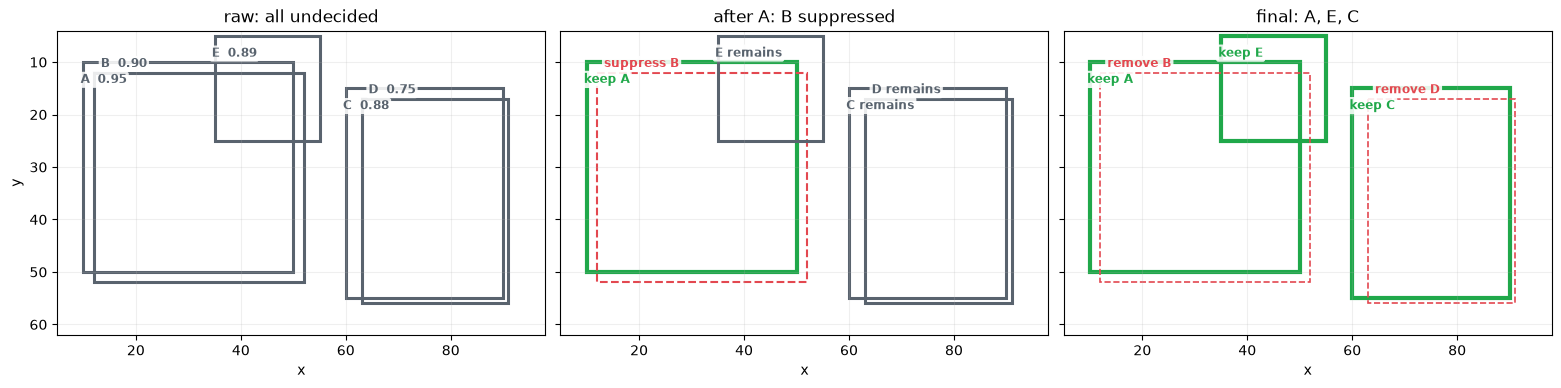

In [5]:
def draw_box(ax, box, label, color, offset=(0,-13), ls='-', lw=2.2):
    x0,y0,x1,y1 = box
    ax.add_patch(Rectangle((x0,y0),x1-x0,y1-y0,fill=False,ec=color,lw=lw,ls=ls))
    ax.annotate(label, (x0,y0), xytext=offset, textcoords='offset points',
                color=color, weight='bold', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=.18', fc='white', ec='none', alpha=.88))

fig, axes = plt.subplots(1,3,figsize=(15.5,4.6),sharex=True,sharey=True, constrained_layout=True)
offsets = [(-2,-15),(5,4),(-2,-15),(-2,-15),(5,4)]
for i in range(5):
    draw_box(axes[0], boxes[i], f'{names[i]}  {scores[i]:.2f}', SLATE, offsets[i])
axes[0].set_title('raw: all undecided')
draw_box(axes[1],boxes[0],'keep A',GREEN,(-2,-15),lw=3)
draw_box(axes[1],boxes[1],'suppress B',RED,(5,4),ls='--',lw=1.5)
for i, label in [(2,'E remains'),(3,'C remains'),(4,'D remains')]:
    draw_box(axes[1],boxes[i],label,SLATE,offsets[i])
axes[1].set_title('after A: B suppressed')
for i, label in [(0,'keep A'),(2,'keep E'),(3,'keep C')]:
    draw_box(axes[2],boxes[i],label,GREEN,offsets[i],lw=3)
draw_box(axes[2],boxes[1],'remove B',RED,(5,4),ls='--',lw=1.2)
draw_box(axes[2],boxes[4],'remove D',RED,(5,4),ls='--',lw=1.2)
axes[2].set_title('final: A, E, C')
for ax in axes:
    ax.set(xlim=(5,98),ylim=(62,4),xlabel='x'); ax.grid(alpha=.2); ax.set_aspect('equal')
axes[0].set_ylabel('y'); plt.show()

## 4 · `INFER` — sweep the IoU threshold

**Predict:** in this held scene of two duplicate pairs plus isolated E, does a larger threshold suppress more boxes or fewer boxes? Greedy NMS survivor counts are **not** guaranteed to be monotone for every possible overlap graph.

In [6]:
for threshold in [.3,.5,.8,.9]:
    kept,_ = nms(boxes,scores,threshold)
    print(f'tau={threshold:.1f}: keep {names[kept].tolist()}')

# This assertion is specific to this disjoint-pair scene, not a theorem about greedy NMS.
counts = [len(nms(boxes,scores,t)[0]) for t in np.linspace(0,1,51)]
assert np.all(np.diff(counts) >= 0)

tau=0.3: keep ['A', 'E', 'C']
tau=0.5: keep ['A', 'E', 'C']
tau=0.8: keep ['A', 'E', 'C']
tau=0.9: keep ['A', 'B', 'E', 'C', 'D']


## 5 · `INFER` — why NMS is usually class-aware

Add a **hand** box H that overlaps cup box A. Class-agnostic NMS may remove H; per-class NMS should keep one cup near each object **and** the hand.

**Predict:** which comparison must be forbidden to preserve H?

In [7]:
boxes6 = np.vstack([boxes, [9,9,49,49]])
scores6 = np.r_[scores,.87]
names6 = np.append(names,'H')
classes6 = np.append(classes,'hand')

agnostic,_ = nms(boxes6,scores6,.5)

def class_aware_nms(boxes,scores,classes,threshold=.5):
    keep=[]
    for cls in np.unique(classes):
        idx=np.flatnonzero(classes==cls)
        local,_=nms(boxes[idx],scores[idx],threshold)
        keep.extend(idx[local])
    return sorted(keep,key=lambda i:scores[i],reverse=True)

aware=class_aware_nms(boxes6,scores6,classes6,.5)
agnostic_labels=[(str(names6[i]),str(classes6[i])) for i in agnostic]
aware_labels=[(str(names6[i]),str(classes6[i])) for i in aware]
print('class-agnostic:',agnostic_labels)
print('class-aware   :',aware_labels)
assert 'H' not in names6[agnostic] and 'H' in names6[aware]

class-agnostic: [('A', 'cup'), ('E', 'cup'), ('C', 'cup')]
class-aware   : [('A', 'cup'), ('E', 'cup'), ('C', 'cup'), ('H', 'hand')]


## 6 · `INFER` — put scoring, thresholding and NMS together

A dense head forms each class score as $s_{cup}=o\,p(cup\mid object)$. Treat A–E's held scores as already formed, append candidate F with $o=.20$ and $p(cup\mid object)=.99$, remove scores below $0.30$, then run cup NMS.

**Predict:** can a candidate with high class probability still be removed by the score threshold?

In [8]:
f_objectness, f_p_cup_given_object = .20, .99
f_score = f_objectness * f_p_cup_given_object
cup_score = np.r_[scores, f_score]
pipeline_boxes = np.vstack([boxes, [20,45,35,60]])
pipeline_names = np.append(names,'F')
mask = cup_score >= .30
kept_local,_ = nms(pipeline_boxes[mask],cup_score[mask],.5)
final_idx = np.flatnonzero(mask)[kept_local]
print('held class scores A–E:', scores.tolist())
print(f'F: {f_objectness:.2f} x {f_p_cup_given_object:.2f} = {f_score:.3f}')
print('after score threshold:',pipeline_names[mask].tolist())
print('after NMS            :',pipeline_names[final_idx].tolist())
assert pipeline_names[final_idx].tolist() == ['A','E','C']

held class scores A–E: [0.95, 0.9, 0.89, 0.88, 0.75]
F: 0.20 x 0.99 = 0.198
after score threshold: ['A', 'B', 'E', 'C', 'D']
after NMS            : ['A', 'E', 'C']


## 7 · `INFER` boundary — try to break NMS

Create two **distinct same-class objects** whose correct boxes overlap. Give the slightly higher-scoring one priority. Find a threshold that wrongly suppresses the other.

Then explain one possible remedy: raise $\tau$, use Soft-NMS to decay rather than delete, or use a learned/set-based alternative. There is no universally safe threshold.

In [9]:
nearby = np.array([[10,10,40,50],[24,10,54,50]],float)
nearby_scores = np.array([.92,.90])
overlap = iou(nearby[0],nearby[1])
print(f'IoU between two distinct-object boxes = {overlap:.3f}')
for threshold in [.25,.35,.50,.70]:
    k,_=nms(nearby,nearby_scores,threshold)
    print(f'tau={threshold:.2f}: keep {len(k)} object(s)')

IoU between two distinct-object boxes = 0.364
tau=0.25: keep 1 object(s)
tau=0.35: keep 1 object(s)
tau=0.50: keep 2 object(s)
tau=0.70: keep 2 object(s)


## Explain the trace

1. Why is B compared with A before D is compared with C?
2. Why does increasing $\tau$ keep more boxes in this scene, yet not guarantee a globally monotone survivor count for every greedy overlap graph?
3. Why is class-aware NMS appropriate for an overlapping cup and hand?
4. What information does standard NMS ignore that a learned post-processor might use?

## Takeaway

- NMS is an `INFER`-clock greedy algorithm on **decoded boxes + scores**, not a learned layer.
- Its order matters: the current maximum claims a neighbourhood before the next survivor is considered.
- Class-aware NMS prevents cross-class suppression, but nearby same-class objects remain a genuine failure mode.
- In the held scene NMS keeps A, E, C; on the `EVAL` clock, one-to-one matching later marks A and C TP and isolated E FP.